Importerar alla libraries som krävs för att kunna köra filen.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

%matplotlib inline

Läser in datan från en csv fil mha. pandas.
    Skriver även ut beskrivande inforamtion om datan med print, head och describe metoderna.

In [3]:
# Läs in data filen
wholesale = pd.read_csv('Wholesale customers data.csv')

# Visar radantal och kolumner med data.
print(wholesale)
# Visa de första raderna
wholesale.head()
# Visa variabler som antal, medel etc.
wholesale.describe()


     Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  
0          1338  
1          1776  
2          7844  
3          1788  
4          5185  
..          ...

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


Använder en scatterplot för att översiktligt utforska datan. Vi kan se hur mycket pengar spenderas i var grupp

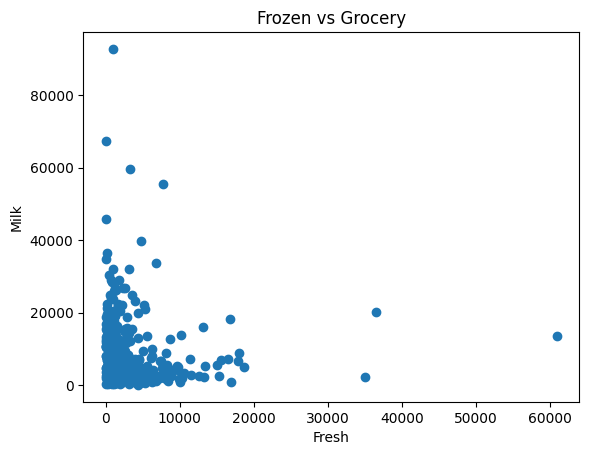

In [4]:
plt.scatter(wholesale['Frozen'], wholesale['Grocery'])
plt.xlabel('Fresh')
plt.ylabel('Milk')
plt.title('Frozen vs Grocery')
plt.show()

Vi använder även en boxplot för att utforska datan. Här kan vi se hur mycket pengar spenderas per grupp. Vi kan även läsa ut om grupperna ligger på samma nivå.

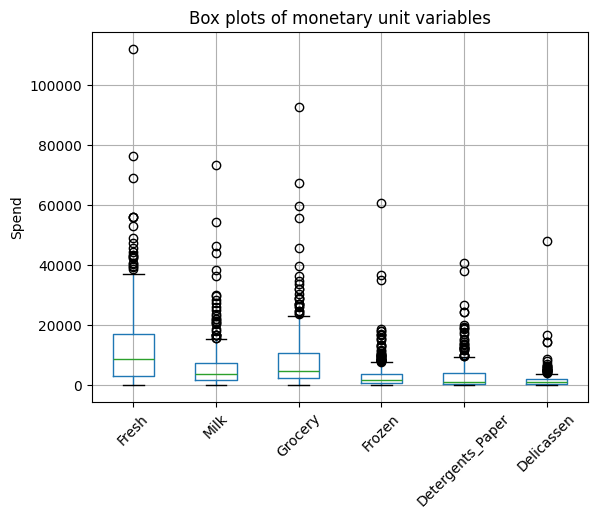

In [5]:
# Select the monetary-unit columns
mu_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

wholesale[mu_cols].boxplot(rot=45)
plt.title('Box plots of monetary unit variables')
plt.ylabel('Spend')
plt.show()


Här har vi ett dendogram vilket visar på hur grupperna ungefärligt kommer att fördelas. Vi kan även bestämma k-värde utifrån denogrammet. De mindre grupperna kan ses som "outliers"

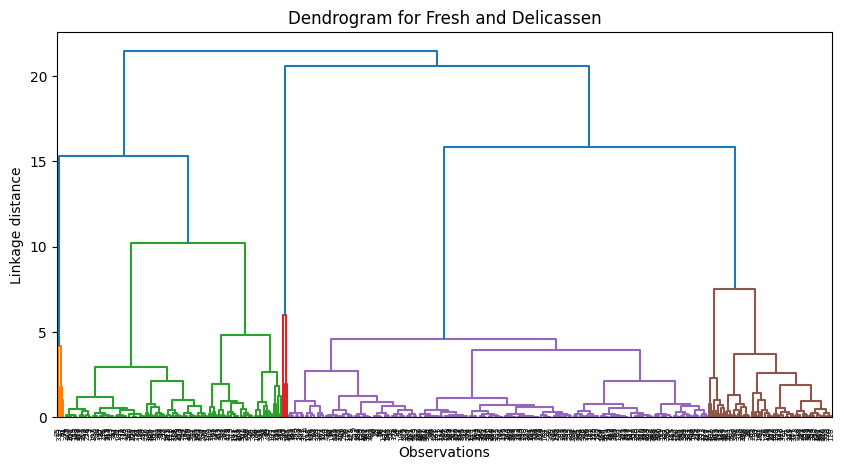

In [8]:

# Select the two features
data = wholesale[['Frozen', 'Grocery']]

# Scale the data (helps because Fresh is usually much larger in magnitude)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Compute hierarchical linkage
Z = linkage(data_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram for Fresh and Delicassen')
plt.xlabel('Observations')
plt.ylabel('Linkage distance')
plt.show()

Här ser vi nu klustrarna på en scatterplot, som vi bestämt utifrån denogrammet. Vi kan se att de mindre grupperna från dendogrammet faktiskt är outliers, eller sk. högspenderande personer från datasettet.

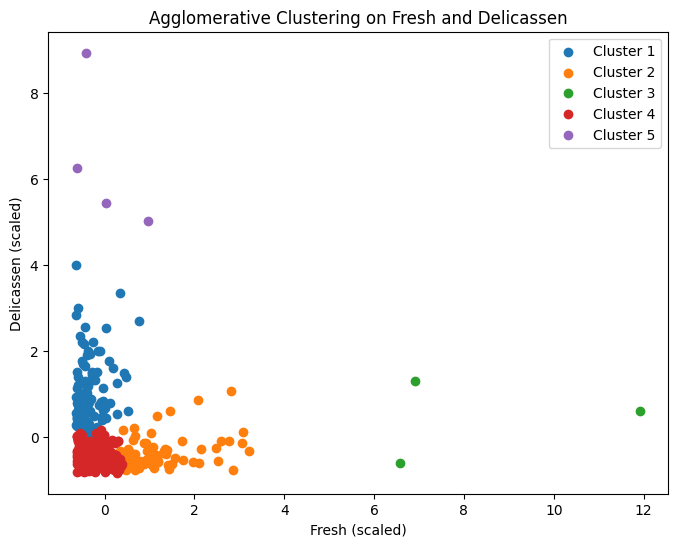

,Fresh,Delicassen
Cluster,,
0,7596.161290,1862.233871
1,20160.242857,1860.557143
2,26959.333333,18750.000000
3,11468.711297,1007.933054
4,26272.500000,3160.250000


In [7]:

# Select the two features
data = wholesale[['Frozen', 'Grocery']]

# Scale the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Choose the number of clusters based on the dendrogram
n_clusters = 5   # change this according to your dendrogram

# Fit agglomerative clustering (no affinity argument)
model = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage='ward'
)

labels = model.fit_predict(data_scaled)

# Plot clusters
plt.figure(figsize=(8,6))
for cluster in range(n_clusters):
    cluster_points = data_scaled[labels == cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster+1}')

plt.xlabel('Fresh (scaled)')
plt.ylabel('Delicassen (scaled)')
plt.title('Agglomerative Clustering on Fresh and Delicassen')
plt.legend()
plt.show()

# Attach cluster labels back to the dataset
wholesale['Cluster'] = labels

wholesale.groupby('Cluster')[['Fresh','Delicassen']].mean()
